<a href="https://colab.research.google.com/github/Almodovare/Training_Data/blob/main/%D0%A1%D1%80%D0%B0%D0%B2%D0%BD%D0%B5%D0%BD%D0%B8%D0%B5_%D0%B3%D1%80%D1%83%D0%BF%D0%BF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import scipy.stats as stats
import matplotlib as plt
%matplotlib inline

In [ ]:
!git clone https://github.com/Almodovare/Training_Data

Cloning into 'Training_Data'...
remote: Enumerating objects: 174, done.
remote: Counting objects: 100% (174/174), done.
remote: Compressing objects: 100% (172/172), done.
remote: Total 174 (delta 50), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (174/174), 34.88 MiB | 7.83 MiB/s, done.
Resolving deltas: 100% (50/50), done.
Updating files: 100% (76/76), done.


In [ ]:
df= pd.read_excel('/content/Training_Data/Real estate SPb.xlsx')
df.sample(7)

,locality_name,total_images,price,total_area,rooms,floors_total,floor,airports_nearest,cityCenters_nearest,parks_nearest
546,Санкт-Петербург,20,29000000,162.9,4,8.0,7,24484.0,5052,253
512,Санкт-Петербург,5,5400000,54.0,2,6.0,2,25242.0,3816,384
907,Санкт-Петербург,16,28000000,100.1,3,8.0,4,26318.0,6516,221
539,Петергоф,11,3200000,44.4,2,5.0,3,36940.0,32129,427
403,Санкт-Петербург,10,4350000,56.0,3,6.0,3,22697.0,11009,541
773,Санкт-Петербург,4,3850000,35.4,1,12.0,4,9569.0,11687,571
464,Санкт-Петербург,18,4450000,50.7,2,5.0,4,15132.0,13673,684


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1093 entries, 0 to 1092
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   locality_name        1092 non-null   object 
 1   total_images         1093 non-null   int64  
 2   price                1093 non-null   int64  
 3   total_area           1093 non-null   float64
 4   rooms                1093 non-null   int64  
 5   floors_total         1092 non-null   float64
 6   floor                1093 non-null   int64  
 7   airports_nearest     1092 non-null   float64
 8   cityCenters_nearest  1093 non-null   int64  
 9   parks_nearest        1093 non-null   int64  
dtypes: float64(3), int64(6), object(1)
memory usage: 85.5+ KB


### Сравнение двух выборок

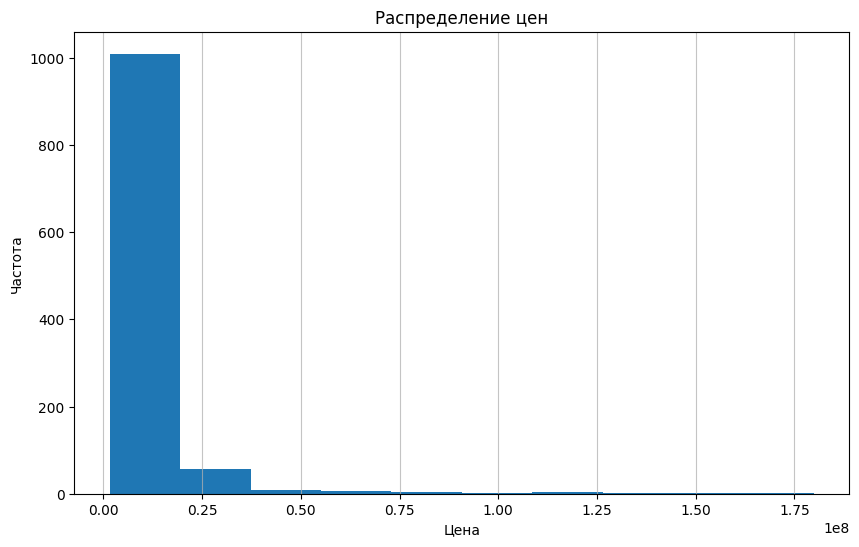

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df.price)
plt.title('Распределение цен')
plt.xlabel('Цена')
plt.ylabel('Частота')
plt.grid(axis='x', alpha=0.75)

In [ ]:
df.locality_name.value_counts()

,count
locality_name,
Санкт-Петербург,982
Пушкин,28
Петергоф,20
Колпино,19
Сестрорецк,15
Кронштадт,10
Красное Село,4
Павловск,4
Ломоносов,4


In [ ]:
# Сформируем две выборки, в которых будем сравнивать количественный показател, например, price

In [ ]:
sample_1 = df.price.sample (n = 400)
sample_2 = df.price.sample (n = 440)

In [ ]:
sample_1.sample(4)

,price
870,17200000
145,6300000
71,4000000
778,16775132


<Axes: >

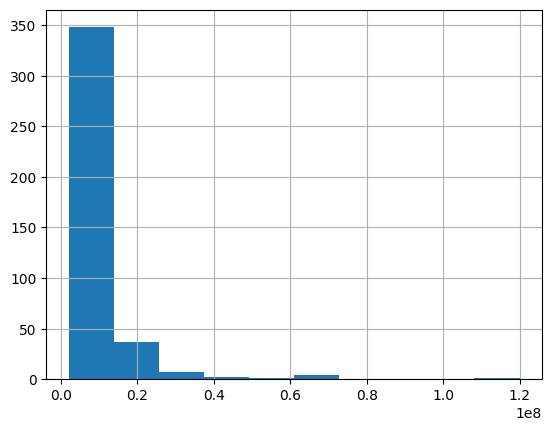

In [ ]:
sample_1.hist()

<Axes: >

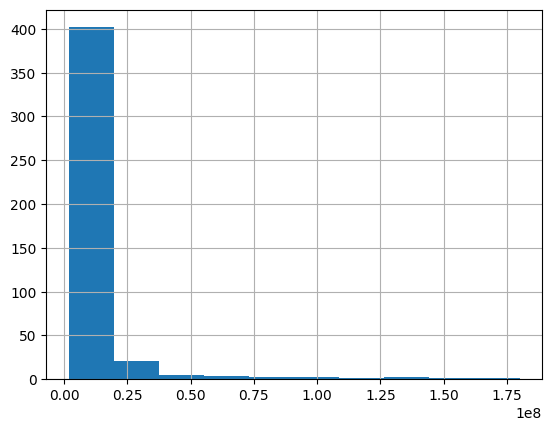

In [ ]:
sample_2.hist()

<Axes: >

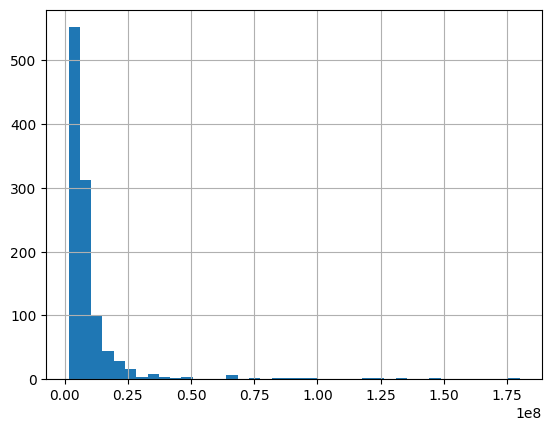

In [ ]:
df.price.hist(bins =40)

In [ ]:
# Визуально данные оцениваются как отклоняющиеся от нормального распределения,
# однако необходимо протестировать. Тест нормальности содержится в модуле scipy.stats - normaltest
# H0: данные взяты из генеральной совокупности, подчиняющейся номальному распределению

In [ ]:
print (stats.normaltest(sample_1))
print (stats.normaltest(sample_2))

NormaltestResult(statistic=np.float64(477.5073702114174), pvalue=np.float64(2.0445231128954233e-104))
NormaltestResult(statistic=np.float64(525.2736236928082), pvalue=np.float64(8.675247432557164e-115))


In [ ]:
# Вывод: поскольку p-value < 0.05,нулевая гипотеза отклоняется и в случае первой выборки,
# и в случае второй выборки. То есть для проверки гипотезы о равенстве двух
# совокупностей необходимо использовать непараметрический метод - U критерий Манна-Уитни

In [ ]:
stats.mannwhitneyu(sample_1,sample_2)

MannwhitneyuResult(statistic=np.float64(85853.0), pvalue=np.float64(0.5410743016733444))

In [ ]:
# Вывод: поскольку p-value> 0,05,нет оснований отклонить Н0,
# то есть центры распределений, из которых взяты данные выборки статистически значимо не отличаются/
# По-другому: цена статистически значимо не отличается в первой и второй выборке

In [ ]:
# В учебных целях проведем сравнение данных групп с помощью t-теста

In [ ]:
stats.ttest_ind(sample_1, sample_2) # t-тест для независимых выборок

TtestResult(statistic=np.float64(-1.8628013788318152), pvalue=np.float64(0.06283992361010293), df=np.float64(838.0))

In [ ]:
st, pval = stats.ttest_ind (sample_1, sample_2)
pval

np.float64(0.06283992361010293)

In [ ]:
# Вывод: поскольку p-val > 0,05, нет оснований отвергнуть Н0.
# то есть средние значения в двух генеральных совокупностях статистически значимо не отличаются

In [ ]:
print (sample_1.mean(), sample_1.std())
print (sample_2.mean(), sample_2.std())

8940263.8025 10182665.3040568
10854913.35909091 18118820.54505017


In [ ]:
# Для сравнения двух зависимых выборок применяется stats.ttest_rel

In [ ]:
# ДЗ. Сделать две совокупности, в которые поместить квартиры первого этажа и квартиры второго этажа
# Сравнить их между собой.